# 파이썬 30회차 기출문제 해답


## 문제 1

**Data description**

개인의 건강 상태를 평가하기 위한 다양한 생물학적 및 생리학적 지표들을 포함하는 건강 검진 데이터입니다.

-   **Age**: 피검자의 나이

-   **Gender**: 피검자의 성별

-   **BMI**: 체질량 지수

-   **FPG**: 공복 시 혈당 수치

-   **Chol**: 혈중 총 콜레스테롤 수치

-   **Tri**: 혈중 트리글리세라이드 수치

-   **HDL**: 혈중 고밀도지단백 콜레스테롤 수치 (High-Density Lipoprotein Cholesterol)

-   **LDL**: 혈중 저밀도지단백 콜레스테롤 수치 (Low-Density Lipoprotein Cholesterol)

-   **ALT**: 간 효소 수치 중 하나로, 알라닌 아미노트랜스페라제 (Alanine Aminotransferase)

-   **DBP**: 이완기 혈압 수치 (Diastolic Blood Pressure)

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
# import time

In [2]:
dat = pd.read_csv('problem1.csv')
dat.head(2)

,Age,Gender,BMI,DBP,FPG,Chol,Tri,HDL,LDL,ALT
0,26,1,20.1,81,5.8,4.36,0.86,0.9,2.43,12.0
1,40,1,17.7,54,4.6,3.70,1.02,1.5,2.04,9.2


칼럼명을 소문자로 변경한다.

In [3]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4303 entries, 0 to 4302
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     4303 non-null   int64  
 1   Gender  4303 non-null   int64  
 2   BMI     4303 non-null   float64
 3   DBP     4303 non-null   int64  
 4   FPG     4303 non-null   float64
 5   Chol    4302 non-null   float64
 6   Tri     4303 non-null   float64
 7   HDL     4303 non-null   float64
 8   LDL     4303 non-null   float64
 9   ALT     4303 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 336.3 KB


`gender` 칼럼을 수치형에서 범주형으로 변환한다.

In [4]:
dat = dat.astype({'Gender' : 'object'})

1.  **EDA를 수행하시오.**

In [5]:
missing_ratio = dat.isnull().mean()
for column, ratio in missing_ratio.items():
    print(f"{column}: {ratio:.2%}")

Age: 0.00%
Gender: 0.00%
BMI: 0.00%
DBP: 0.00%
FPG: 0.00%
Chol: 0.02%
Tri: 0.00%
HDL: 0.00%
LDL: 0.00%
ALT: 0.00%


`chol` 칼럼에 결측치가 0.02% 존재한다.

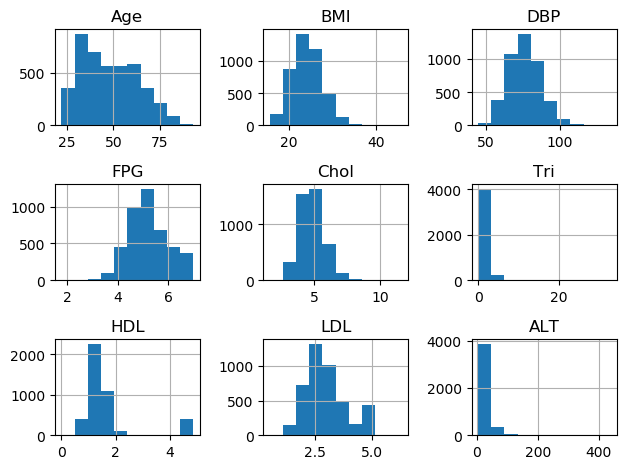

In [6]:
dat.hist();
plt.tight_layout();
plt.show();

수치형 변수의 분포를 히스토그램을 통해 확인한다.

`tri`, `alt` 칼럼의 경우 우측으로 긴꼬리를 갖는 분포 형태이며, 이상치로 의심되는 관측치가 존재한다. `hdl`, `ldl` 칼럼의 경우 대체로 정규분포 형태이며, 특이사항으로 콜레스테롤 수치가 5일 때 빈도가 높은 것을 확인할 수 있다.

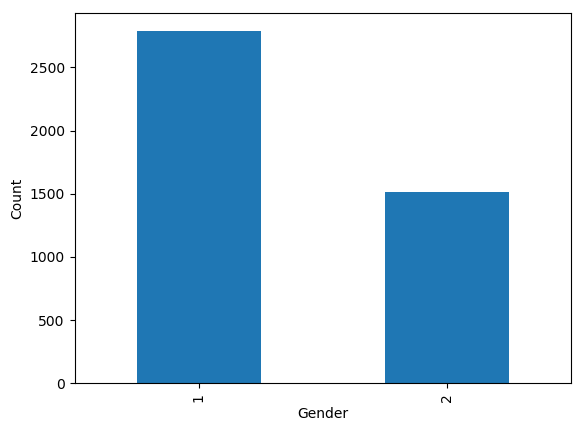

In [7]:
gender_counts = dat['Gender'].value_counts()
gender_counts.plot(kind='bar')

plt.xlabel('Gender');
plt.ylabel('Count');
plt.show();

`gender` 칼럼의 경우 남성의 비율이 여성의 비율에 비해 높은 것을 확인할 수 있다.

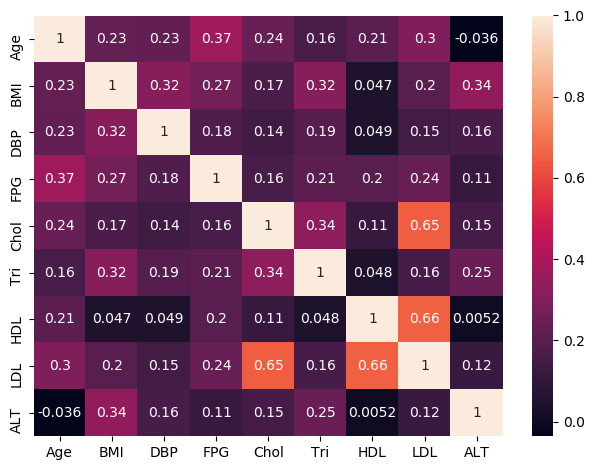

In [8]:
corr = dat.select_dtypes('number').corr()
sns.heatmap(corr, annot = True);
plt.tight_layout()
plt.show();

`hdl`, `ldl` 칼럼 간 상관계수는 0.66으로 높은 양의 상관관계가 존재한다. 마찬가지로 `chol`, `ldl` 칼럼 간 상관계수는 0.65로 높은 양의 상관관계가 존재한다.

2.  **데이터 전처리가 필요하다면 수행하고 이유를 작성하시오.**

EDA 과정에서 확인한 결과 chol 변수에 결측치가 1개 존재한다. 전체 데이터의 약 0.02%이므로, 결측치를 제거한다.

In [9]:
dat = dat.dropna()

3.  **train test set을 DBP 컬럼 기준으로 7:3 비율로 나눈 후 잘 나뉘었는지 통계적으로 나타내시오.**

단순 무작위 샘플링을 통해 훈련 데이터와 테스트 데이터를 7:3으로 분할한다.

In [10]:
y = dat.DBP
X = dat.drop(['DBP'], axis = 1)

from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.3, random_state = 0)

데이터 분할 결과를 확인해보면 다음과 같다.

In [11]:
train_ratio = len(train_X) / len(dat)
test_ratio = len(test_X) / len(dat)

print(f'훈련 데이터 비율: {train_ratio:.1%}')
print(f'테스트 데이터 비율: {test_ratio:.1%}')

훈련 데이터 비율: 70.0%
테스트 데이터 비율: 30.0%


훈련 데이터와 테스트 데이터의 각 칼럼별 분포의 유사성을 통계적으로 비교하고자 한다. 두 분포의 유사성을 통계적으로 검정하는 방법은 K-S 테스트를 활용해볼 수 있다.

In [12]:
from scipy import stats
import pandas as pd

num_col = train_X.select_dtypes('number').columns
result = pd.DataFrame()

for i in range(len(num_col)):
    sample1 = train_X[num_col[i]]
    sample2 = test_X[num_col[i]]
    p_value = stats.ks_2samp(sample1, sample2).pvalue

    tt = pd.DataFrame({'var_name': [num_col[i]], 'P_value': [p_value]})
    result = pd.concat([result, tt], ignore_index=True)

result


,var_name,P_value
0,Age,0.502677
1,BMI,0.511554
2,FPG,0.952331
3,Chol,0.812211
4,Tri,0.368833
5,HDL,0.888398
6,LDL,0.607771
7,ALT,0.022524


-   **귀무가설 (H0)**: 두 칼럼은 동일한 분포를 따른다.

-   **대립가설 (H1)**: 두 칼럼은 동일한 분포를 따르지 않는다.

유의수준 5%에서 p-value \> 0.05이므로, 귀무가설을 기각할 수 없다. 따라서 훈련 데이터와 테스트 데이터의 분포는 통계적으로 동일한 분포하고 볼 수 있다.

4.  **독립변수의 차원축소의 필요성을 논하고, 필요에 따라 차원을 축소하고 불필요하다면 그 근거를 논하시오.**

차원 축소는 변수 간의 중복 정보 제거, 연산 속도 향상, 지도학습 모델 구축시 과적합 방지를 위해 활용할 수 있다. 차원 축소 기법 중 대표적인 방법으로 주성분분석(PCA)이 있으며, 차원 축소의 필요성은 각 변수 간의 상관관계를 보고 판단할 수 있다. EDA 과정에서 확인한 결과 (`hdl`, `ldl`), (`chol`, `ldl`) 칼럼을 제외하면 변수 간 상관관계가 높지 않다. 따라서 차원 축소 고려하지 않는다.

5.  **데이터가 회귀분석의 기본가정 따르는지 설명하시오.**

훈련 데이터를 활용하여 회귀분석을 실시한다.

In [13]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [14]:
all_X_columns = train_X.columns.to_list()
cols_str = " + ".join(all_X_columns)
train = pd.concat([train_X, train_y], axis = 1)

lm_model = smf.ols(formula = f"DBP ~ {cols_str}", data = train).fit()
lm_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    DBP   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     60.67
Date:                Sat, 28 Jun 2025   Prob (F-statistic):          1.88e-102
Time:                        07:20:26   Log-Likelihood:                -11202.
No. Observations:                3011   AIC:                         2.242e+04
Df Residuals:                    3001   BIC:                         2.248e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      51.5567      1.885     27.347      0.000      47.860      55.253
Gender[T.2]    -2.8687      0.415     -6.921      0.000      -3.682      -2.056
Age             0.1134      0.014      8.079      0.000       0.086       0.141
BMI             0.6084      0.062      9.856      0.000       0.487       0.729
FPG             0.4973      0.261      1.907      0.057      -0.014       1.008
Chol            0.0245      0.332      0.074      0.941      -0.626       0.676
Tri             0.5524      0.165      3.342      0.001       0.228       0.877
HDL            -0.1684      0.274     -0.615      0.539      -0.706       0.369
LDL             0.6374      0.436      1.461      0.144      -0.218       1.493
ALT             0.0183      0.009      2.093      0.036       0.001       0.035
==============================================================================
Omnibus:                       98.809   Durbin-Watson:                   2.066
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              128.199
Skew:                           0.365   Prob(JB):                     1.45e-28
Kurtosis:                       3.700   Cond. No.                         659.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

회귀 분석의 기본 가정은 다음과 같다.

-   오차항 평균 0, 등분산

-   오차의 분포는 정규분포

-   오차항은 서로 독립

-   반응변수와 설명변수 관계는 선형

회귀분석의 기본 가정을 확인하기 위해 잔차의 패턴을 분석한다.

**잔차와 예측치(**$\hat{y}_i \quad vs \quad e_i = y_i - \hat{y}_i$) 의 산점도

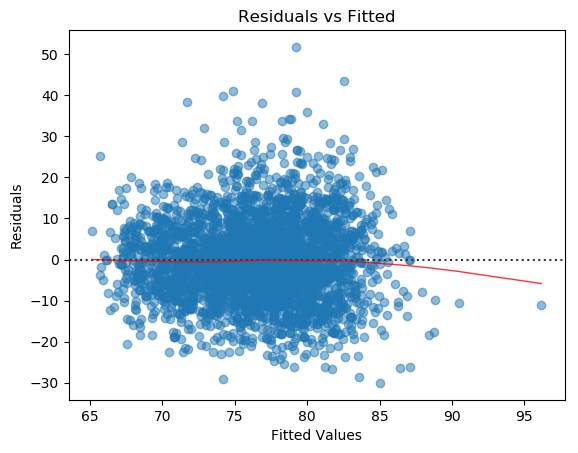

In [15]:
y_fit = lm_model.fittedvalues

#  Plot
sns.residplot(x=y_fit, y='DBP', data=train, lowess=True, 
                     scatter_kws={'alpha': 0.5}, 
                     line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})

plt.title('Residuals vs Fitted')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show();

분산이 증가 or 감소하는 패턴이 없으므로, 등분산 가정을 만족한다. 또한, 잔차의 비선형 패턴이 없으며, 0을 중심으로 무작위로 분포하는 형태이므로 선형성 가정을 만족한다.

2.  **QQ plot : 표준화잔차의 표본 분위수와 정규분포의 이론 분위수와의 산점도**

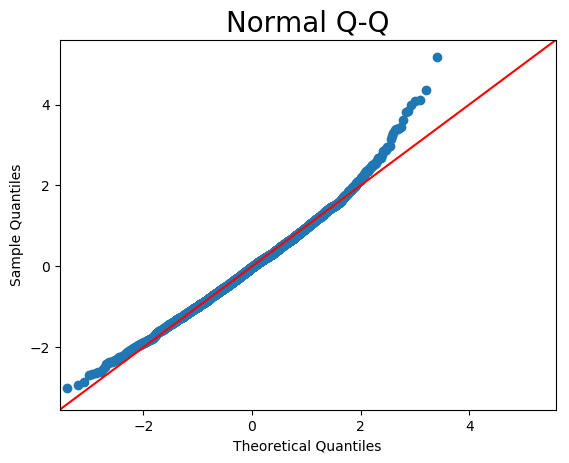

In [16]:
probplot = sm.ProbPlot(lm_model.get_influence().resid_studentized_internal, fit=True)
fig = probplot.qqplot(line='45', color='black')
plt.title('Normal Q-Q', fontsize=20)
plt.show();

양끝 꼬리 부분을 제외하면 대체로 직선 상에 위치해있으므로, 표준화잔차의 표본 분위수와 정규분포의 이론 분위수는 유사하다고 볼 수 있으며, 정규분포 가정을 만족한다.

3.  **표준화 잔차와 예측치의 산점도**

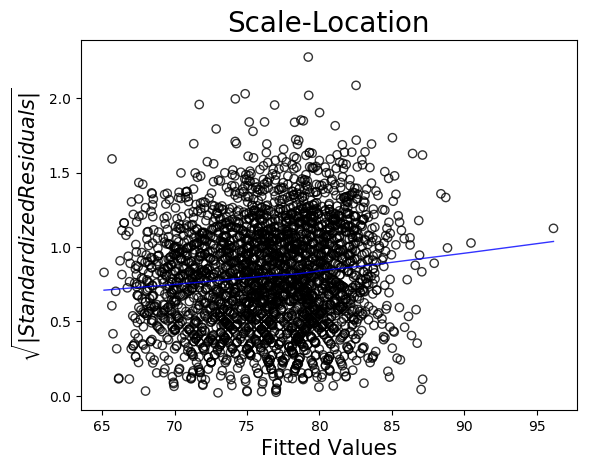

In [17]:
sns.regplot(x = lm_model.fittedvalues, 
           y = np.sqrt(np.abs(lm_model.get_influence().resid_studentized_internal)),
            scatter=True, 
            ci=False, 
            lowess=True,
            line_kws={'color': 'blue', 'lw': 1, 'alpha': 0.8},
          scatter_kws={'facecolors':'none', 'edgecolors':'black'})

plt.title('Scale-Location', fontsize=20)
plt.xlabel('Fitted Values', fontsize=15)
plt.ylabel('$\sqrt{|Standardized Residuals|}$', fontsize=15)
plt.show();

이전과 마찬가지로, 점들이 체계적으로 증가하거나 감소하는 패턴이 없으므로, 등분산 가정을 만족한다.

In [18]:
#sm.stats.durbin_watson(lm_model.resid)
from statsmodels.stats.diagnostic import acorr_ljungbox
ljbox_test = acorr_ljungbox(lm_model.resid, lags = [10])
print(ljbox_test)

     lb_stat  lb_pvalue
10  6.626718   0.760152


-   **귀무가설 (H0)**: 잔차들 간에 자기상관이 없다 (즉, 잔차들이 독립적이다).

-   **대립가설 (H1)**: 잔차들 간에 자기상관이 있다 (즉, 잔차들이 독립적이지 않다).

유의수준 5%에서 p-value = 0.76이므로, 귀무가설을 기각할 수 없다. 따라서 잔차에 자기상관이 존재하지 않으며, 독립성 가정을 만족한다.

1.  **회귀분석 알고리즘 3개를 선택하고 선정이유와 장단점을 비교하시오.**

-   linear regression

-   LASSO regression

-   Random forest

Linear regression 모형은 회귀계수에 대한 직관적인 해석이 용이한 장점이 있지만, 모형에 많은 가정이 있으며, 비선형 모형 대비 예측력이 떨어지는 단점이 있다.위 문제에서 linear regression의 기본 가정을 검토한 결과 모든 가정을 만족하는 것을 볼 수 있다.

LASSO regression 모형은 제약식을 통해서 중요하지 않은 변수의 영향력을 감소시키는 특징이 있으며, 변수선택의 장점이 있다. 반면에 비선형 모형 대비 예측 성능이 떨어지는 단점이 있다.

In [19]:
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
y, X = dmatrices(f"DBP ~ {cols_str}", train, return_type='dataframe')

vif = pd.DataFrame()
vif["column_name"] = X.columns
vif["vif_score"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif.loc[vif.column_name != 'Intercept', :]
vif.round(2)

,column_name,vif_score
1,Gender[T.2],1.16
2,Age,1.29
3,BMI,1.37
4,FPG,1.25
5,Chol,2.90
6,Tri,1.36
7,HDL,2.69
8,LDL,4.58
9,ALT,1.23


분산팽창계수를 확인해보면 ldl, chol변수의 vif \> 3로 다중공선성이 존재하는 것을 확인할 수 있다. LASSO regression의 경우 제약식을 통해 중요하지 않은 변수의 영향력을 감소시킴에 따라 다중공선성의 효과를 완화할 수 있으므로, LASSO regression을 모형으로 활용하고자 한다.

Random forest는 Bagging을 의사결정나무에 적용하여 의사결정나무의 단점인 예측력의 분산이 큰 단점을 보완한 모형이다. Ramdom forest의 경우 비선형모형이고, 모델에 관한 특별한 가정이 없으므로, Linear regression, LASSO regression 모델과의 성능 비교를 위해 활용하고자 한다.

6.  **3개의 회귀 분석 모델링을 진행하고, 평가지표 rmse로 가장 최적화된 알고리즘 선정하시오.**

-   교차 검증 이용

검증 데이터를 통해 모델을 비교하기 위해 5-fold 교차 검증 방법을 적용한다. 5-fold 교차 검증은 훈련 데이터를 임의의 거의 동일한 크기의 5개 그룹(fold)으로 나누는 리샘플링 방법이다.

세부 방법은 다음과 같다.

1.  각 fold 중 $1$ fold는 validation셋으로 취급하고, 나머지 $k-1$개의 fold는 훈련 데이터로 모델 적합에 이용

2.  이러한 절차는 $k$번 반복되며, 매번 다른 그룹의 fold가 validation 셋으로 취급됨

3.  총 $k$ 개의 추정치(ex. MSE)가 계산되며, 최종 CV 추정치는 $k$ 개의 추정치를 평균내서 계산됨

데이터 전처리는 더미 인코딩을 활용한다.

In [20]:
from sklearn.model_selection import GridSearchCV, KFold
cv = KFold(n_splits = 5, shuffle = True, random_state = 0)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_score

from sklearn import set_config
set_config(display="diagram")

In [22]:
cat_columns = train_X.select_dtypes('object').columns.tolist()
cat_preprocess = make_pipeline(
    OneHotEncoder(handle_unknown="ignore", sparse=False)
)

preprocess = ColumnTransformer(
    [("cat", cat_preprocess, cat_columns)]
)

In [23]:
lm_pipe = Pipeline(
    [
        ("preprocess", preprocess),
        ("regressor", LinearRegression())
    ]
)

lasso_pipe = Pipeline(
    [
        ("preprocess", preprocess),
        ("scaler", StandardScaler()),
        ("regressor", Lasso())
    ]
)

rf_pipe = Pipeline(
    [
        ("preprocess", preprocess),
        ("regressor", RandomForestRegressor(random_state=42))
    ]
)

In [24]:
lasso_param = {'regressor__alpha': np.arange(0.1, 1, 0.1)}
RandomForest_param = {'regressor__max_features': np.arange(0.5, 1, 0.1)}

In [25]:
cv_score = cross_val_score(lm_pipe, train_X, train_y, scoring='neg_root_mean_squared_error', cv = cv)
rmse_score = np.absolute(cv_score)
mean_rmse_score = np.mean(rmse_score)

print('교차검증 RMSE score :', mean_rmse_score)

교차검증 RMSE score : 10.647361903133817


In [26]:
lasso_search = GridSearchCV(estimator = lasso_pipe, 
                      param_grid = lasso_param, 
                      cv = cv,
                      scoring = 'neg_root_mean_squared_error')
lasso_search.fit(train_X, train_y)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse=False))]),
                                                                         ['Gender'])])),
                                       ('scaler', StandardScaler()),
                                       ('regressor', Lasso())]),
             param_grid={'regressor__alpha': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])},
             scoring='neg_root_mean_squared_error')

In [27]:
print('best 파라미터 조합 :', lasso_search.best_params_)
print('교차검증 RMSE score :', np.absolute(lasso_search.best_score_))

best 파라미터 조합 : {'regressor__alpha': 0.1}
교차검증 RMSE score : 10.646362223071145


In [28]:
RandomForest_search = GridSearchCV(rf_pipe,
                                   RandomForest_param, 
                                   cv = cv,
                                   scoring = 'neg_root_mean_squared_error')
RandomForest_search.fit(train_X, train_y)

GridSearchCV(cv=KFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse=False))]),
                                                                         ['Gender'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=42))]),
             param_grid={'regressor__max_features': array([0.5, 0.6, 0.7, 0.8, 0.9])},
             scoring='neg_root_mean_squared_error')

In [29]:
print('best 파라미터 조합 :', RandomForest_search.best_params_)
print('교차검증 RMSE score :', np.absolute(RandomForest_search.best_score_))

best 파라미터 조합 : {'regressor__max_features': 0.5}
교차검증 RMSE score : 10.645334909732105


모델별로 RMSE score를 비교해보면 ramdom forest 모형의 성능이 우수한 것을 확인할 수 있다. 따라서 최종 모형으로 Random forest 모형을 선택한다.

In [30]:
pred = RandomForest_search.predict(test_X)
from sklearn.metrics import mean_squared_error
mean_squared_error(pred, test_y, squared = False)

11.189492654630367

최종 검증 데이터에서의 성능은 11.18인 것을 확인할 수 있다.

## 문제 2

**Data description**

교통사고와 관련된 다양한 정보들을 포함하는 사고 기록 데이터입니다.

-   **사고내용**: 사고가 발생한 상황에 대한 설명

-   **가해자성별**: 사고를 일으킨 가해자의 성별

-   **가해자연령**: 사고를 일으킨 가해자의 연령

-   **가해자차종**: 가해자가 운전한 차량의 종류

-   **피해자신체상해정도**: 사고로 인해 피해자가 입은 신체 상해의 정도

-   **사고유형**: 사고의 유형 (예: 추돌, 전복, 충돌 등)

-   **기상상태**: 사고 발생 당시의 기상 상태 (예: 맑음, 비, 눈 등)

-   **사망자수**: 사고로 인한 사망자 수

-   **발생시각**: 사고가 발생한 시간


In [31]:
dat = pd.read_csv('problem2.csv')
dat.head(2)

,사고내용,가해자성별,가해자연령,가해자차종,피해자신체상해정도,사고유형,기상상태,사망자수,발생시각
0,경상,여,75세,자전거,경상,차대차 - 기타,맑음,0,2018-04-03 15시
1,중상,여,26세,자전거,중상,차대차 - 측면충돌,맑음,0,2018-04-21 13시


In [32]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   사고내용       2410 non-null   object
 1   가해자성별      2400 non-null   object
 2   가해자연령      2406 non-null   object
 3   가해자차종      2410 non-null   object
 4   피해자신체상해정도  2410 non-null   object
 5   사고유형       2410 non-null   object
 6   기상상태       2410 non-null   object
 7   사망자수       2410 non-null   int64 
 8   발생시각       2410 non-null   object
dtypes: int64(1), object(8)
memory usage: 169.6+ KB


In [33]:
dat.isna().sum()

사고내용          0
가해자성별        10
가해자연령         4
가해자차종         0
피해자신체상해정도     0
사고유형          0
기상상태          0
사망자수          0
발생시각          0
dtype: int64

가해자성별 10개, 가해자성별 4개의 결측치가 존재하는 것을 확인할 수 있다. 해당 정보는 가해자 신상정보이므로, 결측치를 대치하는 것은 적절하지 않다. 전체 데이터 대비 결측치의 비율이 크지 않으므로 결측치를 삭제한다.

In [34]:
dat = dat.dropna()

가해자연령 칼럼을 수치형으로 변환한다.

In [35]:
#re.sub(r'[^0-9]', '', '18세')
import re

def delete_text(x):
    x = re.sub(r'[^0-9]', '', str(x))
    return x

dat['가해자연령'].apply(lambda x: delete_text(x)).head(3)

0    75
1    26
2    34
Name: 가해자연령, dtype: object

In [36]:
dat['가해자연령'] = dat['가해자연령'].apply(lambda x: delete_text(x))
dat = dat.astype({'가해자연령' : 'int64'})

1.  **평일/주말을 구분하는 ‘주말여부’ 변수를 추가하고 데이터 분포를 확인하시오.**

요일 칼럼을 활용하여 `주말여부` 칼럼을 생성한다.

In [37]:
def delete_text2(x):
    x = re.sub('시', '', str(x))
    return x

dat['발생시각'].apply(lambda x: delete_text2(x)).head(3)

0    2018-04-03 15
1    2018-04-21 13
2    2018-05-01 08
Name: 발생시각, dtype: object

In [38]:
from datetime import datetime
dat['발생시각'] = dat['발생시각'].apply(lambda x: delete_text2(x))
dat['발생시각'] = pd.to_datetime(dat['발생시각'], format='%Y-%m-%d %H')
dat['요일'] = dat['발생시각'].dt.day_name()
dat = dat.assign(주말여부 = np.where(dat['요일'].isin(['Saturday', 'Sunday']), 'Yes', 'No'))
dat = dat.drop(['요일', '발생시각'], axis = 1)

In [39]:
from matplotlib import font_manager, rc
rc('font', family='AppleGothic')            ## 이 두 줄을 
plt.rcParams['axes.unicode_minus'] = False 

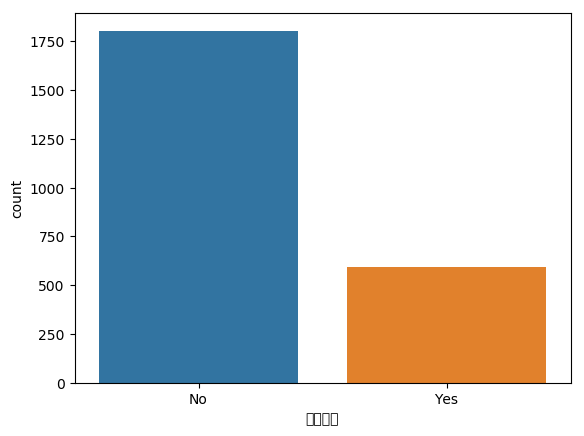

In [40]:
import warnings
warnings.filterwarnings('ignore')
sns.countplot(dat['주말여부'])
plt.show();

주말이 아닌 날이 주말인 날보다 높은 것을 확인할 수 있다.

1.  **주말여부에 따라 각 변수들(사고내용, 가해자성별, 가해자연령, 기상상태, 사고유형)이 통계적으로 유의한지 검정하시오.**

In [41]:
from scipy.stats import chi2_contingency
table1 = pd.crosstab(dat['주말여부'], dat['사고내용'])

chi2, p, df, expected = chi2_contingency(table1)
print('statistics :', np.round(chi2, 2), 'p-value :', np.round(p, 3))

statistics : 3.82 p-value : 0.051


-   **귀무가설 (H0)**: 주말여부와 사고내용은 서로 독립적이다. 즉, 주말 여부가 사고내용에 영향을 미치지 않는다.

-   **대립가설 (H1)**: 주말여부와 사고내용은 서로 독립적이지 않다. 즉, 주말 여부가 사고내용에 영향을 미친다.

독립성 검정 결과 유의 수준 5%에서 p-value = 0.05로 귀무가설을 기각할 수 없다. 따라서 주말 여부와 사고 내용(중상, 경상) 간에는 통계적으로 유의미한 관계가 존재하지 않는다.

In [42]:
table2 = pd.crosstab(dat['주말여부'], dat['가해자성별'])
chi2, p, df, expected = chi2_contingency(table2)
print('statistics :', np.round(chi2, 2), 'p-value :', np.round(p, 3))

N = np.sum(table2.values) 
minimum_dimension = min(table2.shape)-1
Cramer_v = np.sqrt((chi2/N) / minimum_dimension) 
print('Cramer v :', np.round(Cramer_v, 2))

statistics : 11.96 p-value : 0.001
Cramer v : 0.07


-   **귀무가설 (H0)**: 주말여부와 가해자성별은 서로 독립적이다. 즉, 주말 여부가 가해자성별에 영향을 미치지 않는다.

-   **대립가설 (H1)**: 주말여부와 가해자성별은 서로 독립적이지 않다. 즉, 주말 여부가 가해자성별에 영향을 미친다.

독립성 검정 결과 유의 수준 5%에서 p-value = 0.001로 귀무가설을 기각한다. 따라서 주말 여부와 가해자성별 간에는 통계적으로 유의미한 관계가 존재한다. cramer's v = 0.07로 연관성의 강도는 크지 않다.

In [43]:
table3 = pd.crosstab(dat['주말여부'], dat['사고유형'])
chi2, p, df, expected = chi2_contingency(table3)
print('statistics :', np.round(chi2, 2), 'p-value :', np.round(p, 3))

statistics : 1.41 p-value : 0.704


-   **귀무가설 (H0)**: 주말여부와 사고유형은 서로 독립적이다. 즉, 주말 여부가 사고유형에 영향을 미치지 않는다.

-   **대립가설 (H1)**: 주말여부와 사고유형은 서로 독립적이지 않다. 즉, 주말 여부가 사고유형에 영향을 미친다.

독립성 검정 결과 유의 수준 5%에서 p-value = 0.7로 귀무가설을 기각할 수 없다. 따라서 주말 여부와 사고유형(차대차 - 기타, 차대차 - 측면충돌, 차대차 - 추돌, 차대사람 - 기타 ) 간에는 통계적으로 유의미한 관계가 존재하지 않는다.

In [44]:
table4 = pd.crosstab(dat['주말여부'], dat['기상상태'])
chi2, p, df, expected = chi2_contingency(table4)
print('statistics :', np.round(chi2, 2), 'p-value :', np.round(p, 3))

statistics : 5.74 p-value : 0.057


-   **귀무가설 (H0)**: 주말여부와 기상상태은 서로 독립적이다. 즉, 주말 여부가 기상상태에 영향을 미치지 않는다.

-   **대립가설 (H1)**: 주말여부와 기상상태은 서로 독립적이지 않다. 즉, 주말 여부가 기상상태에 영향을 미친다.

독립성 검정 결과 유의 수준 5%에서 p-value = 0.06로 귀무가설을 기각한다. 따라서 주말 여부와 기상상태(맑음, 비, 흐림 ) 간에는 통계적으로 유의미한 관계가 존재한다. cramer's v = 0.04로 연관성의 강도는 크지 않다.

In [45]:
from scipy.stats import ttest_ind

aa1 = dat.loc[dat['주말여부'] == 'Yes', '가해자연령']
aa2 = dat.loc[dat['주말여부'] == 'No', '가해자연령']
ttest_ind(aa1, aa2, equal_var = False)

Ttest_indResult(statistic=-1.5461769343480278, pvalue=0.12239509465305193)

-   **귀무가설 (H0)**: 주말여부에 따른 가해자연령의 평균 차이가 없다.

-   **대립가설 (H1)**: 주말여부에 따른 가해자연령의 평균 차이가 있다.

welch t-test 결과 유의 수준 5%에서 p-value = 0.12로 귀무가설을 기각할 수 없다. 따라서 주말 여부와 가해자연령 간에는 통계적으로 유의미한 관계가 존재하지 않는다.

1.  **SMOTE 오버샘플링하고 변수별 빈도를 나타내고 연속형변수의 경우 평균을 구하시오.**

SMOTE 샘플링을 하기 전에 훈련 데이터와 테스트 데이터를 분할한다. 주말여부 칼럼의 분포를 확인해보면 클래스 불균형이 존재하므로, 층화 샘플링을 통해 훈련데이터와 테스트 데이터를 분할한다.


In [46]:
y = dat['사고내용']
X = dat.drop(['사고내용'], axis = 1)

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, stratify = X['주말여부'], random_state = 0)

훈련 데이터에 SMOTE 샘플링을 적용한다.

-   SMOTE를 적용하기 위해서는 전부 numeric 이어야 하므로 변환 실시

In [47]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_transformer

cat_columns = train_X.select_dtypes('object').columns.to_list()
num_columns = train_X.select_dtypes('number').columns.to_list()

transformer = make_column_transformer(
    (OrdinalEncoder(), cat_columns),
    remainder='passthrough')

encode_data = transformer.fit_transform(train_X)
label_train_X = pd.DataFrame(encode_data, columns = train_X.columns)

-   SMOTE 적용

In [48]:
from collections import Counter
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 0)
train_X_smote, train_y_smote = smote.fit_resample(label_train_X, train_y)
print(Counter(train_y_smote))

Counter({'경상': 1124, '중상': 1124})


-   categorical variable 역변환

In [49]:
aa = transformer.named_transformers_['ordinalencoder']
invese_cat_data = aa.inverse_transform(train_X_smote.iloc[:, :6])  # 핵심 수정
invese_cat_data = pd.DataFrame(invese_cat_data, columns=cat_columns)


-   역변환한 데이터 결합

In [50]:
train_X_smote_sub = pd.DataFrame(train_X_smote, columns = train_X.columns)

train_X_smote_sub = train_X_smote_sub.drop(cat_columns, axis = 1)

train_X_smote = pd.concat([invese_cat_data, train_X_smote_sub], axis = 1)
train_X_smote.head(2)

,가해자성별,가해자차종,피해자신체상해정도,사고유형,기상상태,주말여부,가해자연령,사망자수
0,여,승용차,경상,차대차 - 측면충돌,맑음,No,0.0,45.0
1,남,화물차,경상,차대차 - 기타,맑음,No,2.0,44.0


연속형 변수의 빈도를 나타내면 다음과 같다.

In [51]:
train_X_smote.loc[:, num_columns].mean()

가해자연령     0.407353
사망자수     49.359648
dtype: float64

범주형 변수의 빈도를 나타내면 다음과 같다.

In [52]:
for i in range(len(cat_columns)):
    print(train_X_smote[cat_columns[i]].value_counts())

남    1693
여     555
Name: 가해자성별, dtype: int64
승용차    1619
자전거     365
화물차     264
Name: 가해자차종, dtype: int64
경상    1155
중상    1093
Name: 피해자신체상해정도, dtype: int64
차대차 - 측면충돌    1280
차대차 - 기타       754
차대사람 - 기타      120
차대차 - 추돌        94
Name: 사고유형, dtype: int64
맑음    2150
비       54
흐림      44
Name: 기상상태, dtype: int64
No     1748
Yes     500
Name: 주말여부, dtype: int64


1.  **로지스틱회귀분석, XGBoost 모형을 활용하여 분류분석을 수행하시오.**

In [53]:
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import label_binarize

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_y = le.fit_transform(train_y)
test_y = le.fit_transform(test_y)

In [54]:
cat_preprocess = make_pipeline(
    OneHotEncoder(handle_unknown="ignore", sparse=False)
)

preprocess = ColumnTransformer([('cat', cat_preprocess, cat_columns)], remainder='passthrough')

pipe_lg = Pipeline(
    [
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state = 0)),
        ("classifier", LogisticRegression(solver='liblinear')) 
    ]
)
pipe_lg.fit(train_X, train_y)

cv = KFold(n_splits = 5, shuffle = True, random_state = 0)
cv_score = cross_val_score(pipe_lg, train_X, train_y, scoring='balanced_accuracy', cv = cv)
print('Logistic regression best score : ', np.mean(cv_score))

Logistic regression best score :  0.9876542303827216


In [55]:
import xgboost as xgb
xgb_pipe = Pipeline(
    [
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state = 0)),
        ("classifier", xgb.XGBClassifier()) 
    ]
)

Xgb_param = {'classifier__learning_rate': np.arange(0.01, 0.3, 0.05)}

Xgb_search = GridSearchCV(estimator = xgb_pipe, 
                      param_grid = Xgb_param, 
                      cv = cv,
                      #cv = 5, # KFold 5
                      scoring = 'balanced_accuracy')
Xgb_search.fit(train_X, train_y)

print('xgboost best score : ', Xgb_search.best_score_)

xgboost best score :  0.9876542303827216


모델별로 성능을 비교해보면 Balanced accuracy는 대략 0.98이며, logistic regression의 성능이 가장 좋다. 따라서 최종 모형으로 logistic regression 모형을 선택한다.

In [56]:
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
pred_lg = pipe_lg.predict(test_X)
print(classification_report(test_y, pred_lg))
balanced_accuracy_score(test_y, pred_lg)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       298
           1       1.00      0.99      1.00       182

    accuracy                           1.00       480
   macro avg       1.00      1.00      1.00       480
weighted avg       1.00      1.00      1.00       480



0.9972527472527473

최종 테스트 데이터에서의 성능은 balanced_accuracy = 0.99인 것을 확인할 수 있다.


## 문제 3

별도의 데이터 없음

**아래 데이터는 3개의 철강 제조 공장(공장 A, 공장 B, 공장 C)에서 생산된 제품을 3개의 지역(지역 1, 지역 2, 지역 3)으로 배송할 때 발생하는 운송비용과 공장별 총 생산량, 지역별 총 수요량입니다. 이 데이터를 활용하여 총 운송비를 최소로 하는 운송 계획을 수립하시오. (단, 각 공장에서는 3개 지역으로만 운송되고, 공장 간 또는 지역 간 운송은 없다고 가정한다.)**

표 : 운송비용과 공장별 총 생산량, 지역별 총 수요량

| 구분      | 지역 1 | 지역 2 | 지역 3 | 총 생산량 |
|-----------|--------|--------|--------|-----------|
| 공장 A    | 12만원 | 5만원  | 34만원 | 70개      |
| 공장 B    | 22만원 | 2만원  | 21만원 | 55개      |
| 공장 C    | 3만원  | 23만원 | 15만원 | 25개      |
| 총 수요량 | 30개   | 50개   | 70개   | NA        |

목적 함수 (Objective Function)

$$
\text{minimize } z = 12x_1 + 5x_2 + 34x_3 + 22x_4 + 2x_5 + 21x_6 + 3x_7 + 23x_8 + 15x_9
$$

제약 조건 (Constraints)

원래 제약 조건:

$$
\begin{aligned}
x_1 + x_2 + x_3 & \leq 70 \\
x_4 + x_5 + x_6 & \leq 55 \\
x_7 + x_8 + x_9 & \leq 25 \\
x_1 + x_4 + x_7 & \geq 30 \\
x_2 + x_5 + x_8 & \geq 50 \\
x_3 + x_6 + x_9 & \geq 70 \\
x_1, x_2, x_3, x_4, x_5, x_6, x_7, x_8, x_9 & \geq 0
\end{aligned}
$$ 여기서 $x1$, $x2$, $x3$은 공장A에서 지역 1, 2, 3으로 운송하는 개수를나타내고, $x4$, $x5$, $x6$은 공장B에서 지역 1, 2, 3으로 운송하는 개수, $x7$, $x8$, $x9$은 공장C에서 지역 1, 2, 3으로 운송하는 개수를 나타냅니다.

변환된 제약 조건:

$$
\begin{aligned}
x_1 + x_2 + x_3 & \leq 70 \\
x_4 + x_5 + x_6 & \leq 55 \\
x_7 + x_8 + x_9 & \leq 25 \\
-x_1 - x_4 - x_7 & \leq -30 \\
-x_2 - x_5 - x_8 & \leq -50 \\
-x_3 - x_6 - x_9 & \leq -70 \\
x_1, x_2, x_3, x_4, x_5, x_6, x_7, x_8, x_9 & \geq 0
\end{aligned}
$$

In [57]:
import numpy as np
from itertools import product
from scipy.optimize import linprog

# 비용 행렬
costs = [12, 5, 34, 22, 2, 21, 3, 23, 15]

# 공급량과 수요량
supply = [70, 55, 25]
demand = [30, 50, 70]

# 제약 조건 행렬
A_ub = [
    [1, 1, 1, 0, 0, 0, 0, 0, 0],   # x1 + x2 + x3 ≤ 70
    [0, 0, 0, 1, 1, 1, 0, 0, 0],   # x4 + x5 + x6 ≤ 55
    [0, 0, 0, 0, 0, 0, 1, 1, 1],   # x7 + x8 + x9 ≤ 25
    [-1, 0, 0, -1, 0, 0, -1, 0, 0], # -x1 - x4 - x7 ≤ -30 (x1 + x4 + x7 ≥ 30)
    [0, -1, 0, 0, -1, 0, 0, -1, 0], # -x2 - x5 - x8 ≤ -50 (x2 + x5 + x8 ≥ 50)
    [0, 0, -1, 0, 0, -1, 0, 0, -1], # -x3 - x6 - x9 ≤ -70 (x3 + x6 + x9 ≥ 70)
]

# 제약 조건의 상수
b_ub = [70, 55, 25, -30, -50, -70]

# 선형 계획 문제 해결
result = linprog(c=costs, A_ub=A_ub, b_ub=b_ub, bounds=(0, None), method='highs')

-   최소 운송비용:

In [58]:
print("최적의 운송 비용: ", result.fun)

최적의 운송 비용:  1900.0


-   운송 계획:

In [59]:
print(result.x.reshape(3, 3))

[[20. 50.  0.]
 [ 0.  0. 55.]
 [10.  0. 15.]]


## 문제 4

**Data description**

개인의 헤드셋 보유 정보를 포함하는 데이터입니다.

-   index: 인덱스

-   headset: 헤드셋 종류

-   age: 연령대

In [60]:
dat = pd.read_csv('problem4.csv')

**아래 데이터를 이용하여 헤드셋에 대한 연령대별 선호도 차이가 있는지를 유의 수준 5%로 검정하시오. (단, 반올림하여 소수점 셋째자리까지 표시하시오)**

1.  **연구 가설(H1)과 귀무 가설(H0)을 설정하시오.**

-   H0 : 헤드셋의 종류와 연령대는 서로 독립적이다.
-   H1 : 헤드셋의 종류와 연령대는 서로 독립적이지 않다.

2.  **유의 확률을 계산하고 가설의 채택 여부를 결정하시오.**

In [61]:
# 교차표 생성
cross_tab = pd.crosstab(dat['headset'], dat['age'])

# 카이제곱 독립성 검정 수행
chi2, p, dof, expected = chi2_contingency(cross_tab)

# 결과 출력
print(f'Chi-squared: {chi2:.3f}')
print(f'p-value: {p:.3f}')
print(f'Degrees of freedom: {dof}')
print('Expected frequencies:')
print(expected)

Chi-squared: 3.797
p-value: 0.434
Degrees of freedom: 4
Expected frequencies:
[[24.7  18.2  22.1 ]
 [29.64 21.84 26.52]
 [21.66 15.96 19.38]]


독립성 검정 결과 유의 수준 5%에서 p-value = 0.43로 귀무가설을 기각할 수 없다. 따라서 헤드셋의 종류와 연령대는 서로 연관이 없다.

## 문제 5

별도의 데이터 없음

**각각 6명의 자녀를 가진 다섯 가족이 있다. 각각의 자녀가 아들 또는 딸일 확률은 0.5일 때 아래 질문에 답하시오. (단, 반올림하여 소수점 셋째자리까지 표시하시오.)**

1.  **4명 이상의 딸을 가진 가족이 세 가족 이상일 확률을 0에서 1 사이 숫자로 구하시오.**

먼저 각 가족이 4명 이상의 딸을 가질 확률을 계산합니다. 각각의 자녀가 아들 또는 딸일 확률이 0.5인 이항 분포를 따릅니다.

**4명 이상의 딸을 가질 확률**

이항 분포의 확률 질량 함수(PMF)를 사용하여 계산할 수 있습니다:

$$
P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}
$$ $n = 6$,$k = 4, 5, 6$, 그리고 $p = 0.5$ 입니다.

$$
P(X = 4) = \binom{6}{4} (0.5)^4 (0.5)^2 = \frac{6!}{4!2!} \left(0.5\right)^6 = 15 \times 0.015625 = 0.234375
$$

$$
P(X = 5) = \binom{6}{5} (0.5)^5 (0.5)^1 = \frac{6!}{5!1!} \left(0.5\right)^6 = 6 \times 0.015625 = 0.09375
$$

$$
P(X = 6) = \binom{6}{6} (0.5)^6 (0.5)^0 = \frac{6!}{6!0!} \left(0.5\right)^6 = 1 \times 0.015625 = 0.015625
$$ 

$$
P(X \geq 4) = P(X = 4) + P(X = 5) + P(X = 6) = 0.234375 + 0.09375 + 0.015625 = 0.34375
$$

In [62]:
from scipy.stats import binom

p_3_or_less = binom.cdf(3, n=6, p=0.5)

p_4_or_more = 1 - p_3_or_less

print(f'P(X >= 4): {p_4_or_more:.3f}')

P(X >= 4): 0.344


다음으로 4명 이상의 딸을 가진 가족이 세 가족 이상일 확률을 계산합니다. 이항 분포를 다시 사용합니다. 여기서 $n = 5$, $p = 0.34375$입니다.

$$
P(Y \geq 3) = P(Y = 3) + P(Y = 4) + P(Y = 5)
$$ 

$$
P(Y = 3) = \binom{5}{3} (0.34375)^3 (1-0.34375)^{5-3} = 10 \times (0.34375)^3 \times (0.65625)^2 = 0.175
$$

$$
P(Y = 4) = \binom{5}{4} (0.34375)^4 (1-0.34375)^{5-4} = 5 \times (0.34375)^4 \times (0.65625)^1 = 0.046
$$

$$
P(Y = 5) = \binom{5}{5} (0.34375)^5 (1-0.34375)^{5-5} = 1 \times (0.34375)^5 \times (0.65625)^0 = 0.0045
$$ 

$$
P(Y \geq 3) = P(Y = 3) + P(Y = 4) + P(Y = 5) = 0.175 + 0.046 + 0.0045 = 0.2255
$$

In [63]:
p_2_or_less = binom.cdf(2, n=5, p=p_4_or_more)
p_3_or_more = 1 - p_2_or_less

print(f'P(Y >= 3): {p_3_or_more:.3f}')

P(Y >= 3): 0.226


2.  **다섯 가족 중 몇 가족이 4명 이상의 딸을 가질 것으로 기대되는지 계산하시오.**

이항 분포의 기대값은 평균으로 계산할 수 있습니다.

$$
E(X) = n \times p = 5 \times 0.34375 = 1.71875
$$

In [64]:
5*p_4_or_more

1.71875

약 두 가족이 4명 이상의 딸을 가질 것이라고 예상할 수 있습니다.